# This practice exercise sets us up to apply NLP techniques to Asset Management.

# 1. Introduction

In this notebook we will implement the paper **Lazy Prices** by **Lauren Cohen**, **Christopher J Malloy**, and **Quoc Nguyen**. In this paper we will apply their methods on a small suset of their universe and try to replicate the tables present in their paper. Full paper can be accessed [here](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1658471). We will start the exercise by selecting five stocks followed by downloading the 10-K filings for them from the SEC website. There are a number of things which we need to take care for this which will be mentioned later. We will then clean the text, something which is essential in all NLP tasks followed by calculating the similarity scores. 

# 2. Downloading and importing libraries

We have provided a *requirements.txt* which contains all the python packages which are required to run this notebook. Please place the script and the text file in the same folder to make the code run.

In [1]:
'''
Description -   We download the python packages which are required but not installed on the system currently.
                This cell will take a few minutes to run when it runs for the first time as it will download things from the web.
'''
import sys
!{sys.executable} -m pip install -r requirements.txt

None

Defaulting to user installation because normal site-packages is not writeable


In [2]:
'''
Description -   We import the required packages and functions from the packages which we downloaded.  
                This cell should not throw any error if the above cell ran without any errors.
'''

import pickle
import os
import nltk
import numpy as np
import pandas as pd
import pprint
from tqdm import tqdm
from bs4 import BeautifulSoup
import re
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import requests
from sklearn.metrics.pairwise import cosine_similarity
# import distance # ----> Very slow
# import Levenshtein # ------> Works only for strings
import editdistance

from ratelimit import limits, sleep_and_retry

import yfinance as yf
import pandas_datareader.data as web
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import gc


import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')


from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/svishnoi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/svishnoi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/svishnoi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/svishnoi/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# 3. Selecting firms for which to download 10-K forms

We download 10-K forms and perform the whole analysis for just 5 firms from the DJIA. The dictionary **cik_lookup_DJIA** contains CIK mapping for all firms in DJIA, while the dictionaly **cik_lookup** contains CIK information for 5 of those firms. CIK is Central Index Key, which is used on the SEC's system to uniquely identify a company or an individual which has filed disclosure with SEC.

In [3]:
'''
Description -   The CIK values are taken from the SEC website. The companies which we use in our analysis are  
                AXP-> American Express, AAPL-> Apple, KO-> Coca Cola, JPM-> JP Morgan and Chase, V-> Visa.
'''
cik_lookup_DJIA = {
    'MMM': '0000066740',
    'AXP': '0000004962',
    'AMGN': '0000318154',
    'AAPL': '0000320193',
    'BA': '0000012927',
    'CAT': '0000018230',
    'CVX': '0000093410',
    'CSCO': '0000858877',
    'KO': '0000021344',
    'DIS': '0001001039',
    'DOW': '0000029915',
    'GS': '0000886982',
    'HD': '0000354950',
    'HON': '0000773840',
    'IBM': '0000051143',
    'INTC': '0000050863',
    'JNJ': '0000200406',
    'JPM': '0000019617',
    'MCD': '0000063908',
    'MRK': '0000310158',
    'MSFT': '0000789019',
    'NKE': '0000320187',
    'PG': '0000080424',
    'CRM': '0001108524',
    'TRV': '0000086312',
    'UNH': '0001096938',
    'VZ': '0000732712',
    'V': '0001403161',
    'WBA': '0001618921',    
    'WMT': '0000104169'    
}

cik_lookup = {
    'AXP': '0000004962',
    'AAPL': '0000320193',
    'KO': '0000021344',
    'JPM': '0000019617',
    'V': '0001403161'
}


example_ticker = next(iter(cik_lookup))

In the below cell we will define some variables which we will use while extracting the data from SEC website. The meaning of these variables is given below:
1. **Token**: A unique token is required to access SEC website. Please enter your email-id in place of the current placeholder email. 

2. **MIN_DISTANCE**: {True, False}. When true, it will calculate and save the minimum edit distance between the two documents. This calculation takes some time, so we keep it false but you can try by switching it on. You can read more about the edit distance [here](https://en.wikipedia.org/wiki/Levenshtein_distance).

3. **WITHOUT_STOP**: {True, False}. NLP techniques require us to remove some commonly occurring words from the text before analysing them. This is done because these words don't add any new information. Some examples of these words are 'the', 'is', 'an', etc. You can see the list of such words by printing 'stopwords.words('english')' in a cell. When this variable is true, we keep the documents without removing the stop words.

4. **WITH_STOP**: {True, False}. This is similar to the above variable. When this is true, we save the documents after removing the stop words. If WITH_STOP and WITHOUT_STOP both are true, we save two copies of the documents. If both are False, we force WITHOUT_STOP to be True.

5. **TO_DOWNLOAD**: {True, False}. A value of true to this variable will download new 10-K filings from the SEC website, while a value of false will use the supplied pickle files to load the pre-downloaded 10-K filings. Note that if you give TO_DOWNLOAD =True, you will either need to work on google colab, or connect to some non-CMU wifi. SEC is blocking the IP of CMU wifi, so working from a local jupyter notebook over CMU wifi might result in some errors. If you don't want to use Google Colab or switch to your home wifi, you can always make this variable False and use the pre-supplied pickle files. If you have forced this variable to False, you can skip to [7. Saving and loading data using pickle](#7.-Saving-and-loading-data-using-pickle)

In [65]:
'''
Description -   Setting values to different variables which are required by us during processing of the data.
'''
token = {'User-Agent': "sarthakvishnoi0110@gmail.com"}

MIN_DISTANCE = True
WITHOUT_STOP = False
WITH_STOP = True

if( not(WITHOUT_STOP) and not(WITH_STOP) ):
    WITHOUT_STOP = True
    
TO_DOWNLOAD = False

# 4. Creating class to download SEC Data.

In [66]:
'''
Description -   In this class we define the functions to retrieve data from the SEC website. We first define the limits.
                SEC blocks an IP if it gets more than 10 calls per second from the same IP ( the reason why you cannot do this 
                on CMU wifi).We keep a conservative limit of 5 calls per second. We will use the get() function with the url,
                the data from which we want to read and header, which is nothing but the token which we defined above.
                We end this cell by creating an object of this class which will be used to make all the calls.
'''

class SecAPI(object):
    SEC_CALL_LIMIT = {'calls': 10, 'seconds': 1}

    @staticmethod
    @sleep_and_retry
    # Dividing the call limit by half to avoid coming close to the limit
    @limits(calls=SEC_CALL_LIMIT['calls'] / 2, period=SEC_CALL_LIMIT['seconds'])
    def _call_sec(url, token):
        return requests.get(url, headers = token)

    def get(self, url, header):
        return self._call_sec(url, header).text.encode('latin1').decode('utf-8')
sec_api = SecAPI()

# 5. Functions to process data

In this section we will define various functions which will help us to download the data, structure it properly, lemmatize the text files and help us debug if any error occurs. The functions in order of their definitions and breif descriptions are defined below.

1. **print_ten_k_data**(*ten_k_data*, *fields*, *field_length_limit=50*): This function will be used to print the information in a list of dictionaries. It will print only a certain characters for each field provided. This can be used to check whether the structure of the dictionary is as expected or not.

2. **get_documents**(*doc*): This function will extract documents from the text.

3. **get_document_type**(*doc*): This function will extract the type of document from the text.

4. **remove_html_tags**(*text*): This function will remove the html tags from the text.

5. **clean_text**(*text*): This function will convert the text to lowercase and then remove the html tags from it.

6. **get_sec_data**(*cik*, *doc_types*, *token*, *start=0*, *count=60*):

In [67]:
def print_ten_k_data(ten_k_data, fields, field_length_limit=50):
    """
    Does not return anything, but prints the fields for the dictionary in the list of dictionaries

    Parameters
    ----------
    ten_k_data : list( dict() )
        It holds a list of dictionary. This will mainly be used to save all the information regarding each 10-K
    fields: list( str )
        The fields of the dictionary which we want to print
    field_length_limit: Optional int
        Default value = 50. The max characters that will be printed for each field of the dictionary

    Returns
    -------
    None
    """
    indentation = '  '

    print('[')
    for ten_k in ten_k_data:
        print_statement = '{}{{'.format(indentation)
        for field in fields:
            value = str(ten_k[field])

            # Show return lines in output
            if isinstance(value, str):
                value_str = '\'{}\''.format(value.replace('\n', '\\n'))
            else:
                value_str = str(value)

            # Cut off the string if it gets too long
            if len(value_str) > field_length_limit:
                value_str = value_str[:field_length_limit] + '...'

            print_statement += '\n{}{}: {}'.format(indentation * 2, field, value_str)

        print_statement += '},'
        print(print_statement)
    print(']')

In [68]:
def get_documents(text):
    """
    Extract the documents from the text

    Parameters
    ----------
    text : str
        The text with the document strings inside

    Returns
    -------
    extracted_docs : list of str
        The document strings found in `text`
    """
    
    extracted_docs = re.compile('<DOCUMENT>(.*?)</DOCUMENT>', re.DOTALL | re.IGNORECASE).findall(text)
    return extracted_docs

In [69]:
def get_document_type(doc):
    """
    Return the document type

    Parameters
    ----------
    doc : str
        The document string

    Returns
    -------
    doc_type : str
        The document type
    """

    type_pattern = re.compile(r'<TYPE>[^\n]+')
    doct = type_pattern.findall(doc)
    return doct[0][-4:]

In [70]:
def remove_html_tags(text):
    """
    Return text after removing html tags

    Parameters
    ----------
    text : str
        The document string

    Returns
    -------
    text : str
        The document string after removing the html tags like <br>, <head>, etc
    """
    
    text = BeautifulSoup(text, 'html.parser').get_text()   
    return text

In [71]:
def clean_text(text):
    """
    Return lower case and clean text

    Parameters
    ----------
    text : str
        The document string

    Returns
    -------
    text : str
        The document string after removing the html tags like <br>, <head>, etc and converting all the alphabets to lowercase
    """
    text = text.lower()
    text = remove_html_tags(text)    
    return text

In [72]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

word_pattern = re.compile('\w+')


def lemmatize_words(words):
    """
    Lemmatize words 

    Parameters
    ----------
    words : list of str
        List of words

    Returns
    -------
    lemmatized_words : list of str
        List of lemmatized words
    """
    
    wordnet_lemmatizer = WordNetLemmatizer()
    return [wordnet_lemmatizer.lemmatize(word, pos=wordnet.VERB) for word in words]


In [73]:
def get_sec_data(cik, doc_types, token, start=0, count=60):
    """
    Get a list of documents of doc_types for a cik, between two dates (defined in the function) 

    Parameters
    ----------
    cik : str
        cik for the company ( defined in the dictionary above )
    doc_types: list of str
        we have 10-K here, but we can also download other documents like 10-Q. Just append them to the list
    token: dictionary
        Token defined above
    start, count: int
        Defines how many filings do we need at max

    Returns
    -------
    entries : list of tuples
        Each tuple is of type (url of filing, filing type, filing date)
    """
    
    newest_pricing_data = pd.to_datetime('2017-12-31')
    oldest_pricing_data = pd.to_datetime('1995-01-01')
    rss_urls = []
    for doc_type in doc_types:
        rss_urls.append( 'https://www.sec.gov/cgi-bin/browse-edgar?action=getcompany' \
        '&CIK={}&type={}&start={}&count={}&owner=exclude&output=atom' \
        .format(cik, doc_type, start, count) )
    entries = []
    for rss_url in rss_urls:
        sec_data = sec_api.get(rss_url, token)
        feed = BeautifulSoup(sec_data.encode('utf-8'), 'xml')
        entries.extend( [
            (
                entry.content.find('filing-href').getText(),
                entry.content.find('filing-type').getText(),
                entry.content.find('filing-date').getText())
            for entry in feed.find_all('entry', recursive=True)
            if( (pd.to_datetime(entry.content.find('filing-date').getText()) <= newest_pricing_data) and (pd.to_datetime(entry.content.find('filing-date').getText()) >= oldest_pricing_data) )] )

    return entries

# 6. Downloading data from SEC

In this section, we will use the class and functions defined above to actually download the 10-K files from the SEC. In the cell below, we create a dictionary called **sec_data**, which keeps all the links to 10-K filings from the SEC. These links will then be used with the other functions to download the actual 10-K filings.

In [74]:
if( TO_DOWNLOAD ):
    sec_data = {}
    doc_types = ['10-K']

    count = 60

    for ticker, cik in cik_lookup.items():
        sec_data[ticker] = get_sec_data(cik, doc_types, token, count = count)

    pprint.pprint(sec_data[example_ticker][:5])

The cell below creates a dictionary of list of dictionaries called **ten_ks_by_ticker** which stores the 10-K filings. This below cell will take some time to run. This innermost dictionary has the fields which are defined below:

1. **type** (str): Type of filing. This will be '10-K' for us.
2. **cik** (str): The CIK number for the company
3. **file_date** (str): The date on which this 10-K was filed by the company to SEC.

4. **file_lemma** list(str): if WITHOUT_STOP = True, then this contains the 10-K filing of that company that year, before removing the stopwords. if WITHOUT_STOP = False, then it is an empty list

4. **file_lemma_stop** list(str): if WITH_STOP = True, then this contains the 10-K filing of that company that year, after removing the stopwords. if WITH_STOP = False, then it is an empty list


In [75]:
ten_ks_by_ticker = {}
lemma_english_stopwords = lemmatize_words(stopwords.words('english'))


if( TO_DOWNLOAD ):

    for ticker, data in sec_data.items():
        ten_ks_by_ticker[ticker] = []
        for index_url, file_type, file_date in tqdm(data, desc='Downloading {} Filings'.format(ticker), unit='filing'):
            if (file_type in doc_types):
                file_url = index_url.replace('-index.htm', '.txt').replace('.txtl', '.txt')                        
                raw_filings = sec_api.get(file_url, token)
                filing_documents = get_documents(raw_filings)
                for document in filing_documents:
                    if get_document_type(document) in doc_types:
                        clean_file = clean_text(document)
                        file_lemma = lemmatize_words(word_pattern.findall(clean_file))
                        ten_ks_by_ticker[ticker].append({
                            'type': get_document_type(document),
                            'cik': cik_lookup[ticker],
                            'file_lemma': file_lemma if WITHOUT_STOP else [],
                            'file_lemma_stop': [word for word in file_lemma if word not in lemma_english_stopwords] if WITH_STOP else [],                   
                            'file_date': file_date})

# 7. Saving and loading data using pickle

Pickle is one of the most important and useful packages in python. This is usually used to save and load different python models, dictionaries for sharing between the users. In the cell below we define functions to save and load the dictionary **ten_ks_by_ticker**.

In [76]:
def saveInPickle( filename, currobject ):
    """
    Save currobject in filenam 

    Parameters
    ----------
    filename : str
        The name of the file where we will save the object
    currobject: Python object ( model, object, dictionary)
        The python object which needs to be saved

    Returns
    -------
    None
    """
    if( os.path.isfile(filename) ):
        os.remove( filename )
    pickle.dump(currobject, open( filename, 'ab' ) )

def loadFromPickle( filename ):
    """
    Save currobject in filenam 

    Parameters
    ----------
    filename : str
        The name of the file from where we get the object

    Returns
    -------
        the object loaded from the input file
    """
    
    f=open(filename, 'rb')
    return pickle.load(f)

The below cell just checks whether or not we are able to save and retrieve the object ( created dictionary ) using pickle. This will also save us time as now we don't have to download the data from SEC everytime, but we can just give **TO_DOWNLOAD = False** and just load the object. 

In [77]:
if( TO_DOWNLOAD ):
    filename = 'SEC_DATA_5.pkl'
    saveInPickle( filename, ten_ks_by_ticker)

    obj = loadFromPickle( filename)

    print( obj == ten_ks_by_ticker )

Here, we will see what we can do if we don't want to download the data from SEC website, but just need to use the data which is provided with this notebook. The files which are provided with this notebook are:

1. **SEC_DATA_BEFORE_STOPWORD_REMOVAL_5.pkl**: This file contains the ten_ks_by_ticker. It was created by keeping WITH_STOP = False, and WITHOUT_STOP = True. This is done for the 5 stocks which we have selected.

2. **SEC_DATA_AFTER_STOPWORD_REMOVAL_5.pkl**: This file contains the ten_ks_by_ticker. It was created by keeping WITH_STOP = True, and WITHOUT_STOP = False. This is done for the 5 stocks which we have selected.

3. **SEC_DATA_BEFORE_STOPWORD_REMOVAL.pkl**: This file contains the ten_ks_by_ticker. It was created by keeping WITH_STOP = False, and WITHOUT_STOP = True. This is a big file ( might not run properly on local system ) and contain data for all 30 companies of DJIA.

4. **SEC_DATA_AFTER_STOPWORD_REMOVAL.pkl**: This file contains the ten_ks_by_ticker. It was created by keeping WITH_STOP = True, and WITHOUT_STOP = False.This is a big file ( might not run properly on local system ) and contain data for all 30 companies of DJIA.

For our analysis, we use the file after stop word removal, but you can play around with it. Thus, we use the file **SEC_DATA_AFTER_STOPWORD_REMOVAL_5.pkl**.


In [78]:
if( not( TO_DOWNLOAD) ):
    filename = 'SEC_DATA_AFTER_STOPWORD_REMOVAL_5.pkl'
    ten_ks_by_ticker = loadFromPickle( filename)
    

The below cell uses the function print_ten_k_data for the example ticker. This will also help us to understand the structure of ten_ks_by_ticker, something which we will use heavily in the next few functions to calculate everything.

In [79]:
print_ten_k_data(ten_ks_by_ticker[example_ticker][:5], ['type', 'cik', 'file_lemma', 'file_lemma_stop', 'file_date'])

[
  {
    type: '10-K'
    cik: '0000004962'
    file_lemma: '[]'
    file_lemma_stop: '['10', 'k', '1', 'd321397d10k', 'htm', 'form', '1...
    file_date: '2017-02-17'},
  {
    type: '10-K'
    cik: '0000004962'
    file_lemma: '[]'
    file_lemma_stop: '['10', 'k', '1', 'd131774d10k', 'htm', 'form', '1...
    file_date: '2016-02-19'},
  {
    type: '10-K'
    cik: '0000004962'
    file_lemma: '[]'
    file_lemma_stop: '['10', 'k', '1', 'd862737d10k', 'htm', 'form', '1...
    file_date: '2015-02-24'},
  {
    type: '10-K'
    cik: '0000004962'
    file_lemma: '[]'
    file_lemma_stop: '['10', 'k', '1', 'd656045d10k', 'htm', 'form', '1...
    file_date: '2014-02-25'},
  {
    type: '10-K'
    cik: '0000004962'
    file_lemma: '[]'
    file_lemma_stop: '['10', 'k', '1', 'd486442d10k', 'htm', 'form', '1...
    file_date: '2013-02-22'},
]


# 8. Plots of average length of 10-K and change in average length

We write a code to plot the average length of 10-K each year and how the average length changes over years (Figure 1 in paper). We start by counting the number of words in each of the 10-K and store them in a dictionary where the key is the year of the filing. Along with this we also store

In [80]:
total_words = defaultdict(int) # Sum of words every year
total_words_after_stop = defaultdict(int) # Sum of words after removing stop words
count_filings = defaultdict(int) # Number of filings made that year

for ticker, ten_ks in ten_ks_by_ticker.items():
    for ten_k in tqdm(ten_ks, desc='Counting number of words for {} 10-Ks'.format(ticker), unit=' words'):
        yr = ten_k['file_date'][:4]
        
        count_filings[yr] += 1
        total_words[yr] += len( ten_k['file_lemma'] )
        total_words_after_stop[yr] += len( ten_k['file_lemma_stop'] )

Counting number of words for V 10-Ks: 100%|████████████████████████████| 11/11 [00:00<00:00, 92274.69 words/s]


In the cell below, we calculate the average length of a 10-K each year by taking the ratio of total words and number of filings and storing these numbers in a dictionary.

In [81]:
'''Getting the averages for each year'''
average_word_length = defaultdict(int)
average_word_length_after_stop = defaultdict(int)
for key in count_filings.keys():
    average_word_length[key] = total_words[key] / count_filings[key]
    average_word_length_after_stop[key] = total_words_after_stop[key] / count_filings[key]

Now, we make a pandas dataframe which has index as year and the two columns as the average length of 10-K in those years. This will help us to make the required plots.

In [82]:
'''Making a data frame of these values for easy plotting'''
data = pd.DataFrame( list( average_word_length.items() ) )
data.columns = ['Year', '10_K_avg']
data['10_K_avg_after_stop'] = list( average_word_length_after_stop.values() )
data.set_index('Year', inplace = True)
data.sort_index(inplace=True)
data.head()

,10_K_avg,10_K_avg_after_stop
Year,,
1995,0.0,13497.5
1996,0.0,16137.0
1997,0.0,32616.5
1998,0.0,8373.0
1999,0.0,16964.0


We write a function to create bar plots from a dataframe. The function arguments and return types are defined with the function.

In [83]:
'''Plotting the data'''
def get_bar_plot(x, y, title, y_axis=''):
    """
    Create a bar plot 

    Parameters
    ----------
    x : np.array
        x-axis of the plot
    y : np.array
        y-axis of the plot. The values for which the bar plot is required
    title: str
        Title of the plot
    y_axis: Optional( str )
        Title of y-axis

    Returns
    -------
    None
    """
    
    '''x and y are numpy arrays'''
    fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize=(10,10))

    plt.suptitle(title, fontsize = 25)
    plt.xticks(fontsize=15, rotation = 90)
    plt.yticks(fontsize=15)
    
    plt.bar(x, y ) # Key-value pair
    axes.set_xlabel('Years', fontsize = 15)
    axes.set_ylabel(y_axis, fontsize=15)
    plt.show()

The below two cells makes the bar plots based on the values of **WITH_STOP** and **WITHOUT_STOP** for the average length of 10-K.

In [84]:
if( WITHOUT_STOP ):
    get_bar_plot( data.index, data['10_K_avg'], 'Average Length of 10-K')

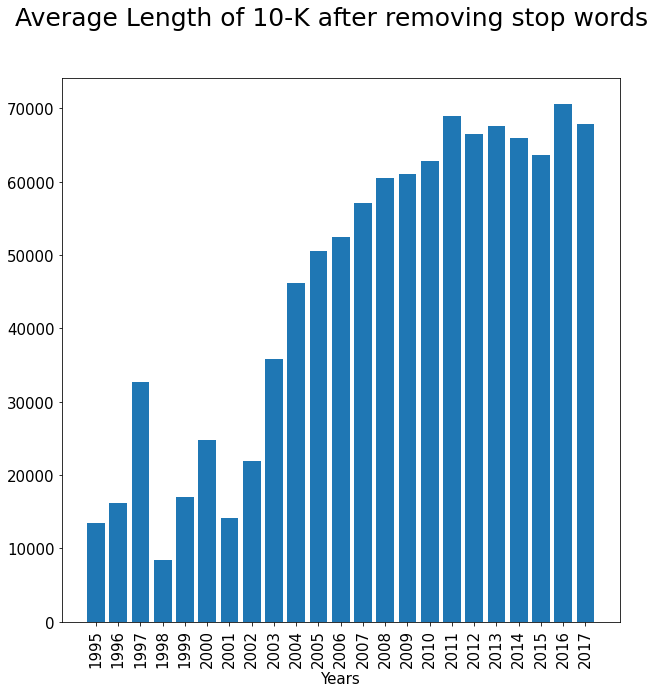

In [85]:
if( WITH_STOP ):
    get_bar_plot( data.index, data['10_K_avg_after_stop'], 'Average Length of 10-K after removing stop words')

We now proceed by calculating the difference in average length of 10-K for each year. We add these columns in the dataframe, the head of which is shown below.

In [86]:
data['10_K_avg_diff'] = data.diff()['10_K_avg']
data['10_K_avg_after_stop_diff'] = data.diff()['10_K_avg_after_stop']
data.head()

,10_K_avg,10_K_avg_after_stop,10_K_avg_diff,10_K_avg_after_stop_diff
Year,,,,
1995,0.0,13497.5,NaN,NaN
1996,0.0,16137.0,0.0,2639.5
1997,0.0,32616.5,0.0,16479.5
1998,0.0,8373.0,0.0,-24243.5
1999,0.0,16964.0,0.0,8591.0


The below two cells makes the bar plots based on the values of **WITH_STOP** and **WITHOUT_STOP** for the change in average length of 10-K.

In [87]:
if( WITHOUT_STOP ):
    get_bar_plot( data.index, data['10_K_avg_diff'], 'Change in Average Length of 10-K')

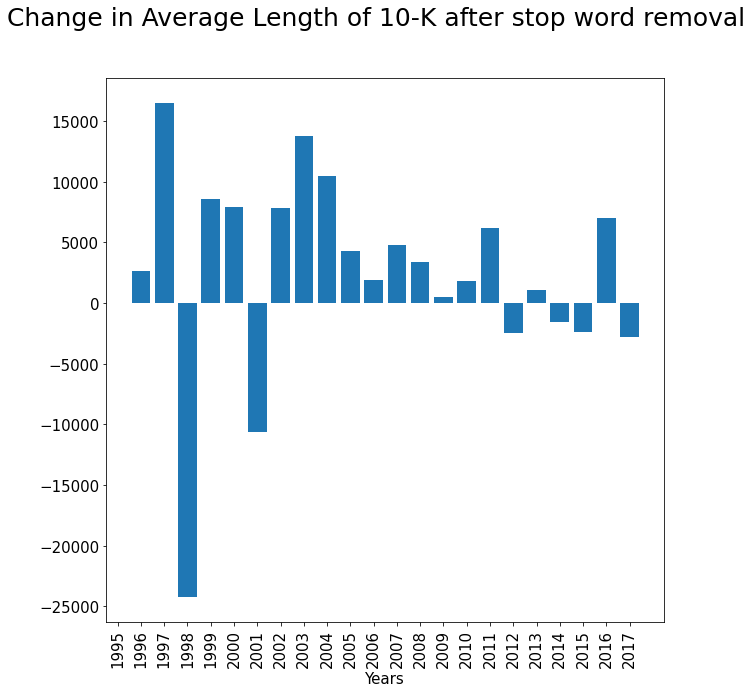

In [88]:
if( WITH_STOP ):
    get_bar_plot( data.index, data['10_K_avg_after_stop_diff'], 'Change in Average Length of 10-K after stop word removal')

# 9. Calculating similarity scores

We calculate 4 different similarity scores between 10-K of a company over the years. These scores are defined below:

1. **Cosine similarity**: When the text is represented as a vector of counts, the cosine of the angle between the two vectors is the cosine similarity score. A score of 1 means that the vectors are overlapping (very similar), while a score of 0 means that the vectors are perpendicular and there is no overlap.

2. **Jaccard similarity**: This is the ratio of the intersection of two documents and union of the two. A score of 1 means that the documents are same while a score of 0 means that there is no similarity between the two documents.

3. **Minimum edit distance**: This is the minimum edit distance ( defined above ). It is basically the number of single character operations ( addition, deletion, replacement ) required to generate one document from the other.

4. **Simple Minimum distance**: This is minimum edit distance which is then scaled to [0,1] using the maximum edit distance.

Note: The calculation of edit distance is a slow operation ( O(n^2) ). We keep MIN_DISTANCE = False, which skips these calculations, but we can try by turning them on. The four cells below define the above four methods.

In [89]:
def get_cosine_similarity( v1, v2 ):
    """
    Calculates the cosine similarity between the two count vectors 

    Parameters
    ----------
    v1, v2 = list of count of different words

    Returns
    -------
    Cosine similarity
    """
    v1 = np.array(v1)
    v2 = np.array(v2)
    
    num = np.dot( v1, v2 )
    den = np.sqrt( np.sum(v1**2) ) * np.sqrt( np.sum(v2**2) )
    return num / den

In [90]:
def get_jaccard_similarity( doc1, doc2 ):
    """
    Calculates the jaccard similarity between the two documents 

    Parameters
    ----------
    doc1, doc2: list of str -> documents between which we need to calculate similarity

    Returns
    -------
    Jaccard similarity between the documents
    """
    
    num = len( set( set(doc1).intersection(set(doc2) ) ) )    
    den = len( set( set(doc1).union(set(doc2) ) ) )
    return num / den

In [91]:
def get_min_distance( doc1, doc2 ):
    """
    Calculates the minimum edit distance between the two documents 

    Parameters
    ----------
    doc1, doc2: list of str -> documents between which we need to calculate similarity

    Returns
    -------
    minimum edit distance between the documents
    """
    d = editdistance.eval( doc1, doc2 )
    return d

In [92]:
def get_simple( max_score, score ):
    """
    Calculates the simple minimum distance between the two documents 

    Parameters
    ----------
    max_score: int 
        It is the global maximum of the minimum edit distance
    score: int
        It is the minimum edit distance of the pair of documents

    Returns
    -------
    simple minimum distance similarity score
    """
    return (max_score - score) / max_score

To calculate cosine similarity, we need a count vector. It is a vector of length equal to the number of distinct words in all the documents and then a count vector for them. This operation is a bit slow ( but much faster compared to calculating edit distances ).

In [93]:
def get_vocab():
    """
    Function to generate a set of words in all the 10-Ks 

    Parameters
    ----------
    None

    Returns
    -------
    Set of distinct words present in all documents
    """
    if( WITHOUT_STOP ):
        key = 'file_lemma'
    else:
        key = 'file_lemma_stop'
    ans = set()
    for ticker, ten_ks in ten_ks_by_ticker.items():
        ticker_ans = set()
        for ten_k in tqdm(ten_ks, desc='Creation of vocabulary. Processing for {} 10-Ks'.format(ticker), unit='10-K'):
            ticker_ans = ticker_ans.union( set(ten_k[key] ) )
        ans = ans.union(ticker_ans)
    ans = list( ans )
    ans.sort()
    return ans

vocab = get_vocab()

Creation of vocabulary. Processing for AXP 10-Ks: 100%|████████████████████| 20/20 [00:00<00:00, 373.6110-K/s]
Creation of vocabulary. Processing for AAPL 10-Ks: 100%|███████████████████| 21/21 [00:00<00:00, 426.5410-K/s]
Creation of vocabulary. Processing for V 10-Ks: 100%|██████████████████████| 11/11 [00:00<00:00, 279.5910-K/s]


In [94]:
def get_count_vector(doc, vocab):
    """
    Generates a count vector for the input doc 

    Parameters
    ----------
    doc: list of str 
        The document for which the count vector needs to be created
    vocab: set of str
        Collection of all the words present in all the documents

    Returns
    -------
    Count vector for the input document
    """
    n = len(vocab)
    ans = np.zeros(n)
    counts = Counter(doc)
    for i in range(n):
        word = vocab[i]
        ans[i] = counts.get(word,0)
    del counts
    gc.collect()
    return ans

In the cell below we create the count vectors for each filing and save them as new keys in ten_ks_by_ticker dictionary.

In [95]:
for ticker, ten_ks in ten_ks_by_ticker.items():
    for ten_k in tqdm(ten_ks, desc='Getting count vectors for {} 10-Ks'.format(ticker), unit=' 10-K'):
        if( WITHOUT_STOP ):
            ten_k['count_vector'] = get_count_vector( ten_k['file_lemma'], vocab )
        if( WITH_STOP ):
            ten_k['count_vector_stop'] = get_count_vector( ten_k['file_lemma_stop'], vocab)

Getting count vectors for V 10-Ks: 100%|███████████████████████████████████| 11/11 [00:02<00:00,  4.72 10-K/s]


We reverse the order of the data so that the data is now in ascending order of the filing date in the list. This makes the next step easier, as now each 10-K comes in order, thus we can save the previous years 10-K without any hassle. **Because this is an inplace operation, please run it only once ( or odd number of times ), and always check if the years are in ascending order or not**.

In [96]:
'''Reversing the years in each ticker'''
for ticker, ten_ks in ten_ks_by_ticker.items():
    ten_ks_by_ticker[ticker].reverse()

In the cell below we try to calculate the different similarity scores based on the global variables ( MIN_DISTANCE, WITH_STOP, WITHOUT_STOP ) between this year's 10-K and the previous years 10-K. The suffix **stop** is added to the keys when calculating the scores for the documents which have been stripped of stopwords. 

In [99]:
c_max = 0
c_max_stop = 0

for ticker, ten_ks in ten_ks_by_ticker.items():
    prev_ten_k = None
    for ten_k in tqdm(ten_ks, desc='Getting similarity scores for {} 10-Ks'.format(ticker), unit=' 10-K'):
        if( not( prev_ten_k == None) ):
            if( WITHOUT_STOP ):
                ten_k['sim_cosine'] = get_cosine_similarity( ten_k['count_vector'], prev_ten_k['count_vector'] )
                ten_k['sim_jaccard'] = get_jaccard_similarity( ten_k['file_lemma'], prev_ten_k['file_lemma'] )
            if( WITH_STOP ):
                ten_k['sim_cosine_stop'] = get_cosine_similarity( ten_k['count_vector_stop'], prev_ten_k['count_vector_stop'] )
                ten_k['sim_jaccard_stop'] = get_jaccard_similarity( ten_k['file_lemma_stop'], prev_ten_k['file_lemma_stop'] )
                
            if( MIN_DISTANCE ):
                if( WITHOUT_STOP ):
                    min_dist = get_min_distance( ten_k['file_lemma'], prev_ten_k['file_lemma'] )
                    ten_k['sim_min_edit'] = 1 - ( min_dist / np.maximum( len( ten_k['file_lemma'] ), len( prev_ten_k['file_lemma'] ) ) ) 
                    ten_k['sim_simple'] = min_dist
                    c_max = np.maximum( min_dist, c_max )
                
                if( WITH_STOP ):
                    min_dist_stop = get_min_distance( ten_k['file_lemma_stop'], prev_ten_k['file_lemma_stop'] )
                    ten_k['sim_min_edit_stop'] = 1 - ( min_dist_stop / np.maximum( len( ten_k['file_lemma_stop'] ), len( prev_ten_k['file_lemma_stop'] ) ) )
                
                    '''Saving distance here, so that I don't have to run it twice'''
                    ten_k['sim_simple_stop'] = min_dist_stop
                    c_max_stop = np.maximum( min_dist_stop, c_max_stop )

        else:
            if( WITHOUT_STOP ):
                ten_k['sim_cosine'] = -1
                ten_k['sim_jaccard'] = -1
            if( WITH_STOP ):
                ten_k['sim_cosine_stop'] = -1
                ten_k['sim_jaccard_stop'] = -1
                
            if( MIN_DISTANCE ):
                if( WITHOUT_STOP ):
                    ten_k['sim_min_edit'] = -1
                    ten_k['sim_simple'] = -1
                if( WITH_STOP ):
                    ten_k['sim_min_edit_stop'] = -1
                    ten_k['sim_simple_stop'] = -1
            
        prev_ten_k = ten_k
        
if( MIN_DISTANCE ):
    for ticker, ten_ks in ten_ks_by_ticker.items():
        prev_ten_k = None
        for ten_k in tqdm(ten_ks, desc='Calculating simple minimum distance for {} 10-Ks'.format(ticker), unit=' 10-K'):
            if( not( prev_ten_k == None) ):
                if( WITHOUT_STOP ):
                    ten_k['sim_simple'] = ( c_max - ten_k['sim_simple'] ) / c_max
                if( WITH_STOP ):
                    ten_k['sim_simple_stop'] = ( c_max_stop - ten_k['sim_simple_stop'] ) / c_max_stop
            prev_ten_k = ten_k

Getting similarity scores for V 10-Ks: 100%|███████████████████████████████| 11/11 [01:09<00:00,  6.34s/ 10-K]
Calculating simple minimum distance for AXP 10-Ks: 100%|████████████████| 20/20 [00:00<00:00, 13344.91 10-K/s]
Calculating simple minimum distance for AAPL 10-Ks: 100%|███████████████| 21/21 [00:00<00:00, 54103.43 10-K/s]
Calculating simple minimum distance for KO 10-Ks: 100%|█████████████████| 20/20 [00:00<00:00, 35605.30 10-K/s]
Calculating simple minimum distance for JPM 10-Ks: 100%|████████████████| 17/17 [00:00<00:00, 14870.32 10-K/s]
Calculating simple minimum distance for V 10-Ks: 100%|██████████████████| 11/11 [00:00<00:00, 66194.18 10-K/s]


For efficient memory use, we now delete the count vectors which we created, they are quite big in size. We only need similarity scores from now on.

In [100]:
for ticker, ten_ks in ten_ks_by_ticker.items():
    for ten_k in tqdm(ten_ks, desc='Freeing memory for {} 10-Ks'.format(ticker), unit=' 10-K'):
        if( WITHOUT_STOP ):
            ten_k['count_vector'] = []
        else:
            ten_k['count_vector_stop'] = []
    gc.collect()

Freeing memory for V 10-Ks: 100%|████████████████████████████████████████| 11/11 [00:00<00:00, 1111.64 10-K/s]


Finally, we make a pandas dataframe, wehere we dump all the information present in the dictionary for better processing. The piece of code below takes care about this, keeping in mind different permutations which can arise due to different set of scores. The structure of this dataframe can be seen in the output.

In [101]:
if( MIN_DISTANCE ):
    '''With min distance'''
    if( WITHOUT_STOP and not(WITH_STOP) ):
        data = pd.DataFrame(columns = ['Year', 'Month', 'Ticker', 'sim_cosine', 'sim_jaccard',\
                                  'sim_min_edit', 'sim_simple'])
    elif(WITHOUT_STOP and WITH_STOP ):
        data = pd.DataFrame(columns = ['Year', 'Month', 'Ticker', 'sim_cosine', 'sim_cosine_stop', 'sim_jaccard', 'sim_jaccard_stop',\
                                  'sim_min_edit', 'sim_min_edit_stop', 'sim_simple', 'sim_simple_stop'])
    else:
        data = pd.DataFrame(columns = ['Year', 'Month', 'Ticker', 'sim_cosine_stop', 'sim_jaccard_stop',\
                                  'sim_min_edit_stop', 'sim_simple_stop'])

else:
    '''Without min distance'''
    if( WITHOUT_STOP and not(WITH_STOP) ):
        data = pd.DataFrame(columns = ['Year', 'Month', 'Ticker', 'sim_cosine', 'sim_jaccard'])
    elif(WITHOUT_STOP and WITH_STOP ):
        data = pd.DataFrame(columns = ['Year', 'Month', 'Ticker', 'sim_cosine', 'sim_cosine_stop', 'sim_jaccard', 'sim_jaccard_stop'])
    else:
        data = pd.DataFrame(columns = ['Year', 'Month', 'Ticker', 'sim_cosine_stop', 'sim_jaccard_stop'])
    
for ticker, ten_ks in ten_ks_by_ticker.items():
    for ten_k in tqdm(ten_ks, desc='Creating dataframe for {}'.format(ticker), unit=' 10-K'):
        if( MIN_DISTANCE ):
            if( WITHOUT_STOP and not(WITH_STOP) ):
                data.loc[len(data)] = [ten_k['file_date'][:4], ten_k['file_date'][5:7], ticker, ten_k['sim_cosine'],\
                                  ten_k['sim_jaccard'], ten_k['sim_min_edit'],\
                                  ten_k['sim_simple']]
            elif(WITHOUT_STOP and WITH_STOP ):
                data.loc[len(data)] = [ten_k['file_date'][:4], ten_k['file_date'][5:7], ticker, ten_k['sim_cosine'], ten_k['sim_cosine_stop'],\
                                  ten_k['sim_jaccard'], ten_k['sim_jaccard_stop'], ten_k['sim_min_edit'], ten_k['sim_min_edit_stop'],\
                                  ten_k['sim_simple'], ten_k['sim_simple_stop']]
            else:
                data.loc[len(data)] = [ten_k['file_date'][:4], ten_k['file_date'][5:7], ticker, ten_k['sim_cosine_stop'],\
                                  ten_k['sim_jaccard_stop'], ten_k['sim_min_edit_stop'],\
                                  ten_k['sim_simple_stop']]
        else:
            '''Without min distance'''
            if( WITHOUT_STOP and not(WITH_STOP) ):
                data.loc[len(data)] = [ten_k['file_date'][:4], ten_k['file_date'][5:7], ticker, ten_k['sim_cosine'],\
                                  ten_k['sim_jaccard']]
            elif(WITHOUT_STOP and WITH_STOP ):
                data.loc[len(data)] = [ten_k['file_date'][:4], ten_k['file_date'][5:7], ticker, ten_k['sim_cosine'], ten_k['sim_cosine_stop'],\
                                  ten_k['sim_jaccard'], ten_k['sim_jaccard_stop']]
            else:
                data.loc[len(data)] = [ten_k['file_date'][:4], ten_k['file_date'][5:7], ticker, ten_k['sim_cosine_stop'],\
                                  ten_k['sim_jaccard_stop']]

if( WITHOUT_STOP ):       
    data = data[data['sim_cosine'] > 0 ]
if( WITH_STOP ):
    data = data[data['sim_cosine_stop'] > 0 ]
                   
data.head()

Creating dataframe for V: 100%|███████████████████████████████████████████| 11/11 [00:00<00:00, 386.24 10-K/s]


,Year,Month,Ticker,sim_cosine_stop,sim_jaccard_stop,sim_min_edit_stop,sim_simple_stop
1,1996,03,AXP,0.948495,0.784904,0.510525,0.936349
2,1999,03,AXP,0.878303,0.608055,0.382892,0.899834
3,2000,03,AXP,0.980928,0.788885,0.688535,0.945529
4,2001,03,AXP,0.976279,0.774983,0.574388,0.920814
5,2003,03,AXP,0.906784,0.632839,0.258797,0.805587


In the above dataframe, we have removed the NaN scores. The year and month correspond to the filing year and month of the 10-K. The sim_ scores are the similarity scores with different measures between the 10-K previous year and the current year.

# 10. Relationships between similarity scores

We start by describing the dataframe and observing what are the ranges of different similarity scores. We observe that in general, the cosine scores are quite close for different 10-K forms while the jaccard scores have higher variance in them.

In [102]:
data.describe()

,sim_cosine_stop,sim_jaccard_stop,sim_min_edit_stop,sim_simple_stop
count,84.000000,84.000000,84.000000,84.000000
mean,0.956142,0.727728,0.481801,0.705125
std,0.033447,0.112720,0.148371,0.230961
min,0.803713,0.419218,0.155537,0.000000
25%,0.949775,0.664876,0.388354,0.651042
50%,0.966108,0.758312,0.504461,0.786950
75%,0.974948,0.809322,0.597546,0.849899
max,0.990566,0.886742,0.750000,0.978338


We now study the correlation between these similarity scores to see how each one of them is related to one other.

In [103]:
if( WITHOUT_STOP ):
    if( MIN_DISTANCE ):
        '''With min_dist'''
        print( data[['sim_cosine', 'sim_jaccard', 'sim_min_edit', 'sim_simple']].corr() )
    else:
        '''Without min_dist'''
        print( data[['sim_cosine', 'sim_jaccard']].corr() )
        
if( WITH_STOP ):
    if( MIN_DISTANCE ):
        '''With min_dist'''
        print( data[['sim_cosine_stop', 'sim_jaccard_stop', 'sim_min_edit_stop', 'sim_simple_stop']].corr() )
    else:
        '''Without min_dist'''
        print( data[['sim_cosine_stop', 'sim_jaccard_stop']].corr() )

                   sim_cosine_stop  sim_jaccard_stop  sim_min_edit_stop  \
sim_cosine_stop           1.000000          0.235828           0.678228   
sim_jaccard_stop          0.235828          1.000000           0.209868   
sim_min_edit_stop         0.678228          0.209868           1.000000   
sim_simple_stop           0.068392          0.340911           0.500757   

                   sim_simple_stop  
sim_cosine_stop           0.068392  
sim_jaccard_stop          0.340911  
sim_min_edit_stop         0.500757  
sim_simple_stop           1.000000  
